# Mapping Florida's old and new congressional districts

Florida was one of the states that redrew its congressional map for the 120th Congress
(see `redistricting_changes.ipynb` for the population-level analysis). This notebook
draws the old (119th Congress) and new (120th Congress) district maps side by side,
highlighting districts 12 and 15 so the change in their boundaries is easy to spot.

## A simplification worth noting
Census blocks are not perfectly clipped to the shoreline - some blocks along the coast
and around lakes include a bit of water. Blocks that are 100% water are dropped once
they pass a minimum size (`MIN_WATER_BLOCK_AREA_M2`), so large water bodies like the
open bay around the Florida Keys render as water, while small ponds and canals stay
part of the land silhouette.

Dropping those water-only blocks leaves small notches along the coastline, and raising
`MIN_WATER_BLOCK_AREA_M2` to drop more/bigger lakes makes that worse. We clean this up
in three steps: a morphological closing (`CLOSE_BUFFER_M`) fills the notches; a light
simplification (`SIMPLIFY_TOLERANCE_M`) smooths the remaining block-edge jaggedness;
and a small opening (`SPIKE_OPEN_M`) snips off thin "spike" artifacts that simplifying
a rounded, buffered coastline can leave behind at narrow inlets. All four constants are
tunable if you want a different tradeoff between detail and cleanliness.

## Required data
This notebook needs the TIGER/Line 2020 census block shapefile for Florida
(`tl_2020_12_tabblock20.zip`), placed in `data/`. See the README for where to get it.

In [1]:
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
# Plot styling
# NOTE: I use dark mode for my notebooks; the plots will therefore look
# nicer if you use dark mode in your browser on GitHub.

INK = "#FFFFFF"

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.facecolor": "#FFFFFF",
    "savefig.facecolor": "#FFFFFF",
    "axes.titlecolor": INK,
    "text.color": INK,
    "font.size": 12,
})

WATER_COLOR = "#FFFFFF"
LAND_COLOR = "#ECE0D0"
BOUNDARY_COLOR = "#2E2D31"
OVERLAY_ALPHA = 1.
HIGHLIGHT_COLORS = {"01": "#5481F5", "03": "#000C48"}  # district -> overlay color

## Load data

In [3]:
DATA_DIR = Path("data")
FIPS = "37"
ABBR = "NC"

# NAD83(HARN) / Florida GDL Albers - a projected, meters-based CRS suited to
# statewide Florida maps. We need real distance units for the smoothing below.
PROJECTED_CRS = "EPSG:3086"

# Blocks that are 100% water are dropped only past this size, so small ponds/canals
# stay part of the land silhouette and only large water bodies (bays, the ocean) show as water.
MIN_WATER_BLOCK_AREA_M2 = 5_000_000

# Dropping water-only blocks near the coast leaves small notches in the land silhouette.
# A morphological closing (buffer out, then back in) fills those without changing the
# overall shape. SIMPLIFY_TOLERANCE_M then smooths the remaining block-edge jaggedness -
# but simplifying a buffered, rounded coastline can turn narrow inlets into thin "spike"
# artifacts. A final light opening (shrink, then re-grow by SPIKE_OPEN_M) snips those off.
CLOSE_BUFFER_M = 300
SIMPLIFY_TOLERANCE_M = 150
SPIKE_OPEN_M = 60

In [4]:
def load_cd_assignments(geoid_and_cd: pd.DataFrame, cd_column: str) -> pd.DataFrame:
    """Reduces a block assignment file to just GEOID and a renamed district column."""
    return geoid_and_cd[["GEOID", "CDFP"]].rename(columns={"CDFP": cd_column})


new_cd_df = load_cd_assignments(pd.read_csv(DATA_DIR / f"CD120_{FIPS}.txt", dtype=str), "new_cd")

with zipfile.ZipFile(DATA_DIR / "cd119.zip") as zf:
    with zf.open("NationalCD119.txt") as f:
        national_cd119 = pd.read_csv(f, dtype=str)

old_cd_df = load_cd_assignments(national_cd119, "old_cd")
old_cd_df = old_cd_df[old_cd_df["GEOID"].str[:2] == FIPS]

print(old_cd_df.shape, new_cd_df.shape)

(236638, 2) (236638, 2)


In [5]:
def load_state_blocks_gdf(fips: str) -> gpd.GeoDataFrame:
    """Loads TIGER/Line 2020 census block geometries for one state.

    Blocks that are 100% water are dropped once their area passes
    MIN_WATER_BLOCK_AREA_M2, so district polygons don't bulge out over large
    bodies of water (e.g. open bay/ocean blocks in the Florida Keys) while
    small ponds and canals stay part of the land silhouette.

    Args:
        fips: Two-digit state FIPS code, matching the shapefile's name.

    Returns:
        GeoDataFrame with GEOID and geometry (in PROJECTED_CRS), one row per
        land-containing census block.
    """
    path = DATA_DIR / f"tl_2020_{fips}_tabblock20/tl_2020_{fips}_tabblock20.shp"
    gdf = gpd.read_file(path).to_crs(PROJECTED_CRS)
    all_water = gdf["ALAND20"] == 0
    gdf = gdf[~(all_water & (gdf["AWATER20"] > MIN_WATER_BLOCK_AREA_M2))]
    return gdf[["GEOID20", "geometry"]].rename(columns={"GEOID20": "GEOID"})


blocks_gdf = load_state_blocks_gdf(FIPS)
blocks_gdf = blocks_gdf.merge(old_cd_df, on="GEOID", how="inner").merge(new_cd_df, on="GEOID", how="inner")
blocks_gdf.shape

(236399, 4)


In [6]:
def dissolve_districts(blocks_gdf: gpd.GeoDataFrame, cd_column: str) -> gpd.GeoDataFrame:
    """Dissolves block geometries into one polygon per congressional district.

    The result is smoothed in three steps: a morphological closing (buffer out,
    then back in) fills the small notches left by dropped water-only blocks;
    a light simplification removes leftover block-edge jaggedness; and a small
    opening (buffer in, then back out) snips off the thin "spike" artifacts
    that simplifying a rounded, buffered coastline can leave at narrow inlets.

    Args:
        blocks_gdf: Block-level geometries joined to district assignments.
        cd_column: Name of the district column to dissolve by.

    Returns:
        GeoDataFrame with one row per district: cd, geometry.
    """
    districts = blocks_gdf[[cd_column, "geometry"]].dissolve(by=cd_column).reset_index()
    districts = districts.rename(columns={cd_column: "cd"})
    closed = districts.geometry.buffer(CLOSE_BUFFER_M).buffer(-CLOSE_BUFFER_M)
    simplified = closed.simplify(SIMPLIFY_TOLERANCE_M, preserve_topology=True)
    districts["geometry"] = simplified.buffer(-SPIKE_OPEN_M).buffer(SPIKE_OPEN_M)
    return districts


old_districts_gdf = dissolve_districts(blocks_gdf, "old_cd")
new_districts_gdf = dissolve_districts(blocks_gdf, "new_cd")

# Same physical state either way, so either map's districts union into the same land shape.
land_geometry = new_districts_gdf.union_all()

0     01
1     02
2     03
3     04
4     05
5     06
6     07
7     08
8     09
9     10
10    11
11    12
12    13
13    14
Name: cd, dtype: str


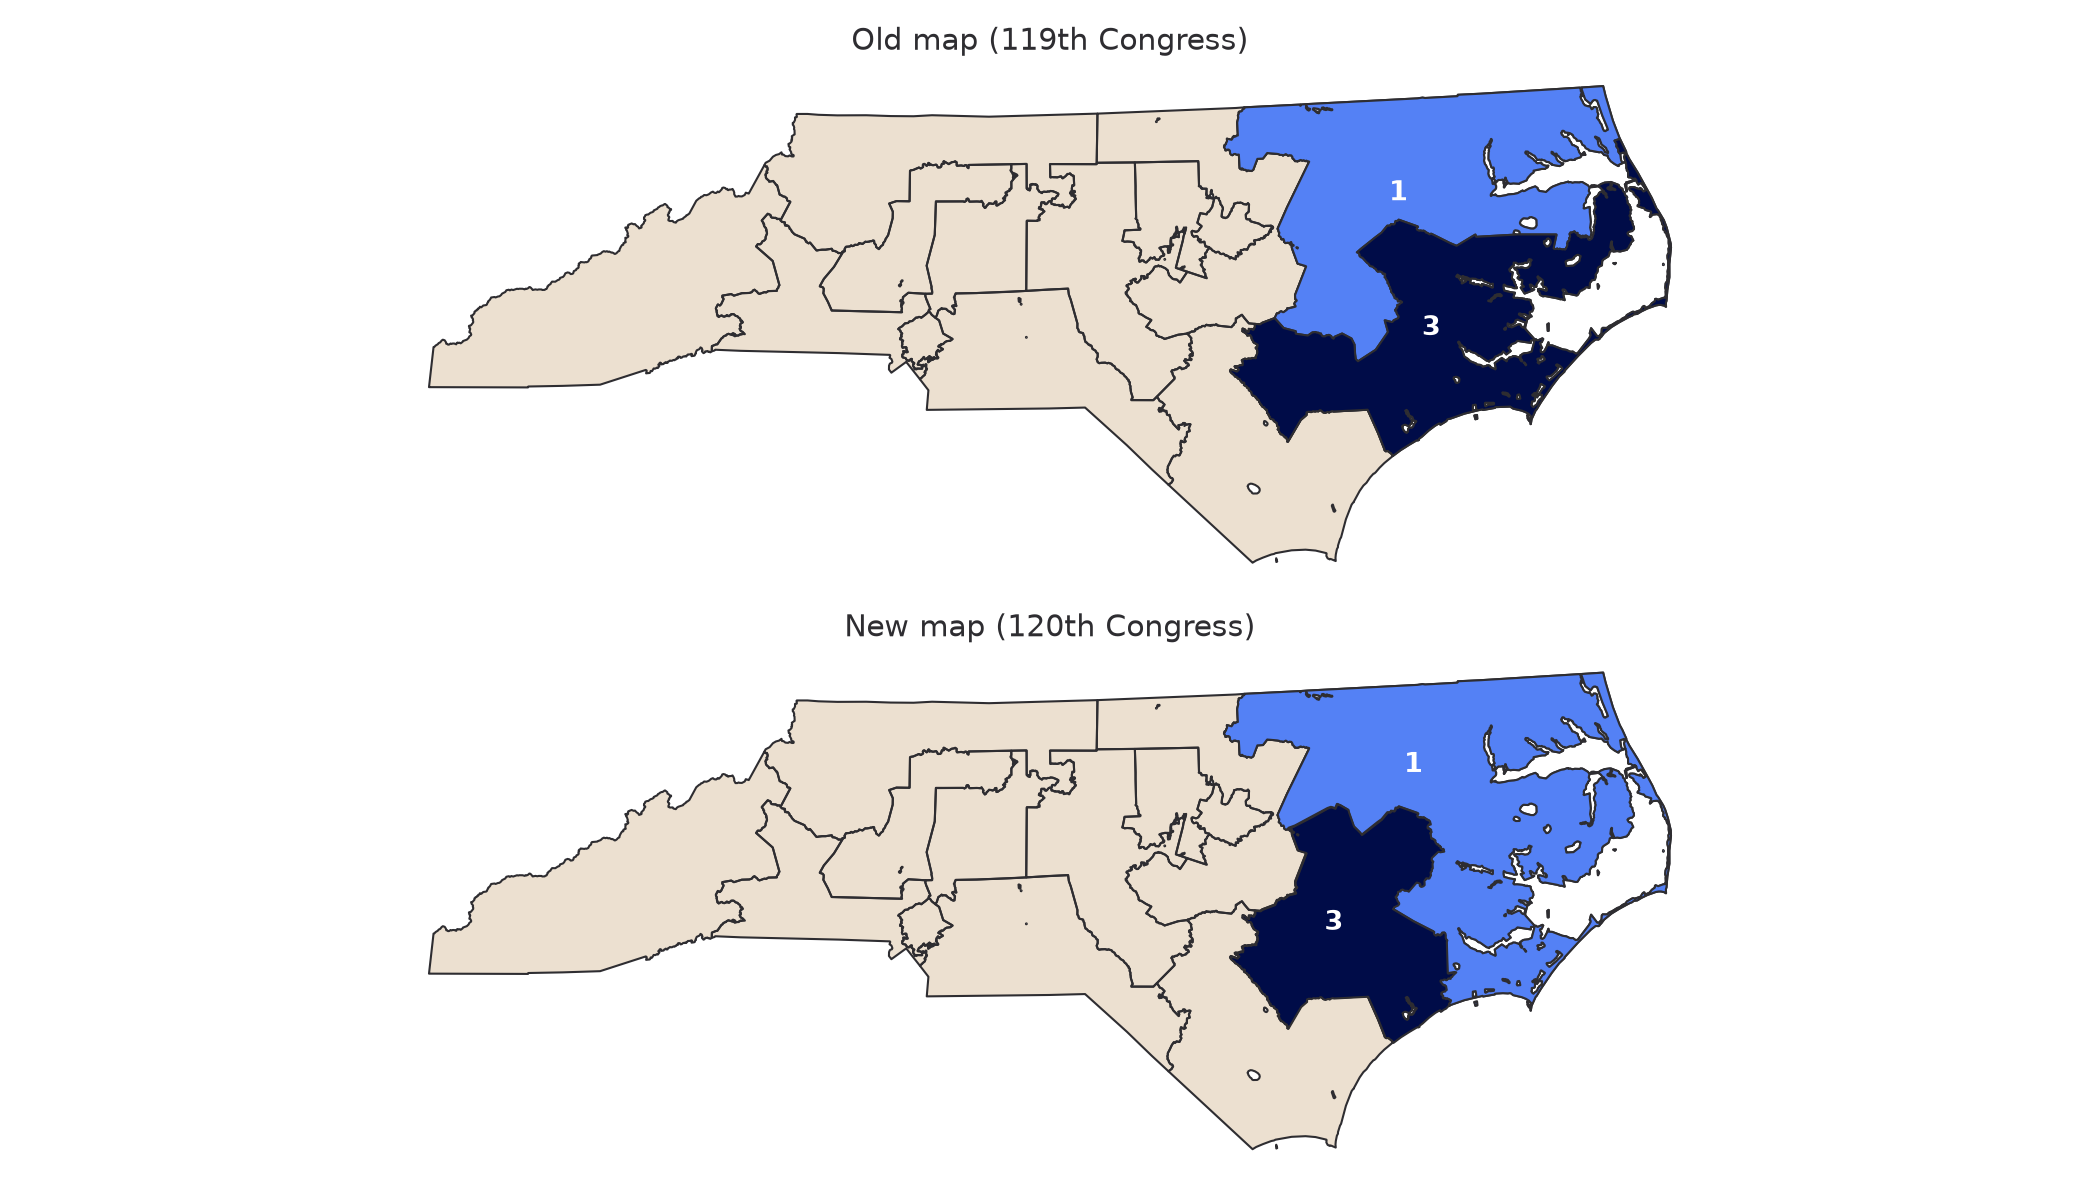

In [42]:
def plot_district_map(ax: plt.Axes, districts_gdf: gpd.GeoDataFrame, title: str, offset = (0,0,0,0)) -> None:
    """Draws one map: water background, green land, black district boundaries,
    with districts 1 and 3 highlighted and labeled."""
    ax.set_facecolor(WATER_COLOR)
    gpd.GeoSeries([land_geometry]).plot(ax=ax, color=LAND_COLOR, edgecolor="none")
    districts_gdf.plot(ax=ax, facecolor="none", edgecolor=BOUNDARY_COLOR, linewidth=1)

    for cd, color in HIGHLIGHT_COLORS.items():
        district = districts_gdf[districts_gdf["cd"] == cd]
        district.plot(ax=ax, facecolor=color, alpha=OVERLAY_ALPHA, edgecolor=BOUNDARY_COLOR, linewidth=1)
        label_point = district.geometry.iloc[0].representative_point()
        if cd == '01':
            xloc = label_point.x + offset[0]
            yloc = label_point.y + offset[1]
        if cd == '03':
            xloc = label_point.x + offset[2]
            yloc = label_point.y + offset[3]
        ax.text(
            xloc, yloc, cd[1:],
            ha="center", va="center", fontsize=13, fontweight="bold", color="white",
        )

    minx, miny, maxx, maxy = land_geometry.bounds
    pad_x, pad_y = (maxx - minx) * 0.05, (maxy - miny) * 0.05
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_axis_off()
    ax.set_title(title, color = '#2E2D31')


fig, (ax_old, ax_new) = plt.subplots(2, 1)
plot_district_map(ax_old, old_districts_gdf, "Old map (119th Congress)", offset = (40000,20000,-8000,-20000))
plot_district_map(ax_new, new_districts_gdf, "New map (120th Congress)", offset = (-60000,50000.,0., 0.))
plt.tight_layout()
plt.savefig('nc_maps.png', bbox_inches='tight')
plt.show()